In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

In [48]:
teams = pd.read_csv("teams.csv")

In [49]:
teams

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3


In [50]:
teams= teams[["team","country","year","athletes","age","prev_medals","medals"]]

In [51]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [52]:
import seaborn as sns

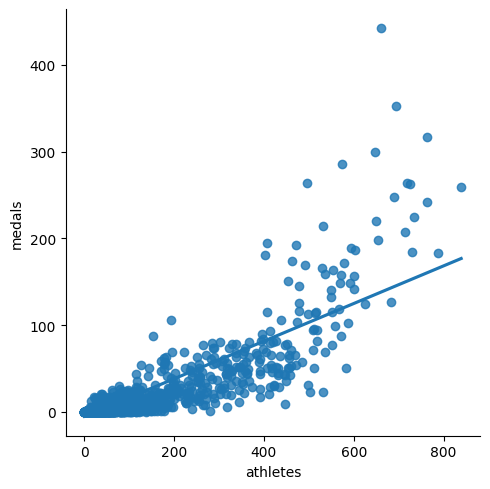

In [53]:
sns.lmplot(x="athletes",y="medals",data=teams,fit_reg= True, ci= None)

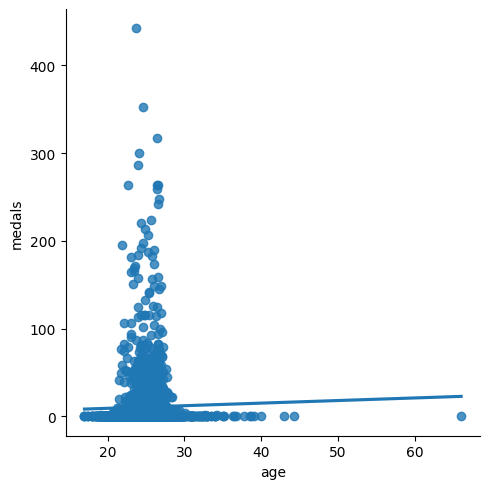

In [54]:
sns.lmplot(x="age",y="medals",data=teams,fit_reg= True, ci= None)

<Axes: ylabel='Frequency'>

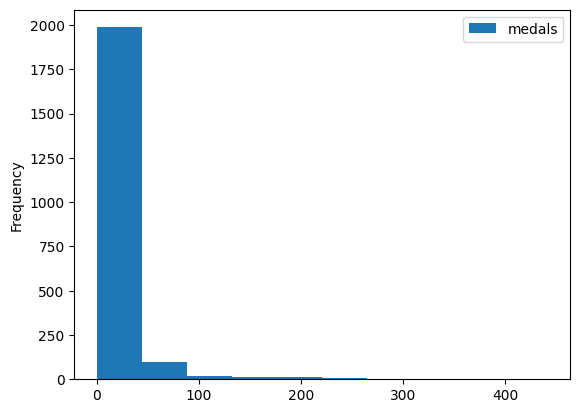

In [55]:
teams.plot.hist(y="medals")

In [56]:
teams[teams.isnull().any(axis=1)]

,team,country,year,athletes,age,prev_medals,medals
19,ALB,Albania,1992,9,25.3,NaN,0
26,ALG,Algeria,1964,7,26.0,NaN,0
39,AND,Andorra,1976,3,28.3,NaN,0
50,ANG,Angola,1980,17,17.4,NaN,0
59,ANT,Antigua and Barbuda,1976,17,23.2,NaN,0
...,...,...,...,...,...,...,...
2092,VIN,Saint Vincent and the Grenadines,1988,6,20.5,NaN,0
2103,YAR,North Yemen,1984,3,27.7,NaN,0
2105,YEM,Yemen,1992,8,19.6,NaN,0
2112,YMD,South Yemen,1988,5,23.6,NaN,0


In [57]:
teams= teams.dropna()

In [58]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [59]:
train= teams[teams["year"]<2012].copy()
test = teams[teams["year"]>=2012].copy()

In [60]:
train.shape

(1609, 7)

In [61]:
test.shape

(405, 7)

In [62]:
from sklearn.linear_model import LinearRegression
reg= LinearRegression()

In [63]:
predictors = ["athletes","prev_medals"]
target = "medals"

In [64]:
reg.fit(train[predictors], train["medals"])

LinearRegression()

In [65]:
LinearRegression()

LinearRegression()

In [66]:
predictions = reg.predict(test[predictors])

In [67]:
test["predictions"] = predictions

In [68]:
test

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,-0.961221
7,AFG,Afghanistan,2016,3,24.7,1.0,0,-1.176333
24,ALB,Albania,2012,10,25.7,0.0,0,-1.425032
25,ALB,Albania,2016,6,23.7,0.0,0,-1.711847
37,ALG,Algeria,2012,39,24.8,2.0,1,2.155629
...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,-1.926958
2131,ZAM,Zambia,2012,7,22.6,0.0,0,-1.640143
2132,ZAM,Zambia,2016,7,24.1,0.0,0,-1.640143
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,1.505767


In [69]:
test.loc[test["predictions"]<0,"predictions"]=0

In [70]:
test["predictions"] = test["predictions"].round()

In [71]:
test

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,0.0
7,AFG,Afghanistan,2016,3,24.7,1.0,0,0.0
24,ALB,Albania,2012,10,25.7,0.0,0,0.0
25,ALB,Albania,2016,6,23.7,0.0,0,0.0
37,ALG,Algeria,2012,39,24.8,2.0,1,2.0
...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,0.0
2131,ZAM,Zambia,2012,7,22.6,0.0,0,0.0
2132,ZAM,Zambia,2016,7,24.1,0.0,0,0.0
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,2.0


In [72]:
from sklearn.metrics import mean_absolute_error
errors = mean_absolute_error(test["medals"], test["predictions"])

In [73]:
errors

3.2987654320987656

In [74]:
test[test["team"]== "USA"]

,team,country,year,athletes,age,prev_medals,medals,predictions
2053,USA,United States,2012,689,26.7,317.0,248,285.0
2054,USA,United States,2016,719,26.4,248.0,264,236.0


In [75]:
test[test["team"]== "IND"]

,team,country,year,athletes,age,prev_medals,medals,predictions
907,IND,India,2012,95,26.0,3.0,6,7.0
908,IND,India,2016,130,26.1,6.0,2,12.0


In [76]:
errors = (test["medals"] - predictions) . abs()

In [77]:
errors

6       1.961221
7       1.176333
24      1.425032
25      1.711847
37      1.155629
          ...   
2111    1.926958
2131    1.640143
2132    1.640143
2142    1.505767
2143    0.080748
Name: medals, Length: 405, dtype: float64

In [78]:
error_by_team = errors.groupby(test["team"]) . mean()

In [79]:
error_by_team

team
AFG    1.568777
ALB    1.568439
ALG    1.535133
AND    1.783551
ANG    0.322667
         ...   
VIE    1.231905
VIN    1.891106
YEM    1.891106
ZAM    1.640143
ZIM    0.793257
Name: medals, Length: 204, dtype: float64

In [80]:
error_by_team = test["medals"]. groupby(test["team"]).mean()

In [81]:
error_by_team

team
AFG    0.5
ALB    0.0
ALG    1.5
AND    0.0
ANG    0.0
      ... 
VIE    1.0
VIN    0.0
YEM    0.0
ZAM    0.0
ZIM    0.0
Name: medals, Length: 204, dtype: float64

In [82]:
medals_by_team = test["medals"].groupby(test["team"]).mean()

In [83]:
error_ratio = error_by_team / medals_by_team

In [84]:
error_ratio

team
AFG    1.0
ALB    NaN
ALG    1.0
AND    NaN
ANG    NaN
      ... 
VIE    1.0
VIN    NaN
YEM    NaN
ZAM    NaN
ZIM    NaN
Name: medals, Length: 204, dtype: float64

In [85]:
error_ratio [~pd.isnull(error_ratio)]

team
AFG    1.0
ALG    1.0
ARG    1.0
ARM    1.0
AUS    1.0
      ... 
UKR    1.0
USA    1.0
UZB    1.0
VEN    1.0
VIE    1.0
Name: medals, Length: 97, dtype: float64

In [86]:
import numpy as np
error_ratio = error_ratio[ np.isfinite(error_ratio)]

In [87]:
error_ratio

team
AFG    1.0
ALG    1.0
ARG    1.0
ARM    1.0
AUS    1.0
      ... 
UKR    1.0
USA    1.0
UZB    1.0
VEN    1.0
VIE    1.0
Name: medals, Length: 97, dtype: float64

<Axes: ylabel='Frequency'>

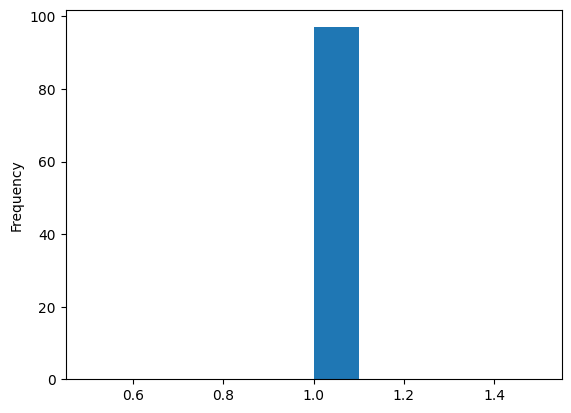

In [88]:
error_ratio.plot.hist()

In [89]:
error_ratio.sort_values()

team
AFG    1.0
ALG    1.0
ARG    1.0
ARM    1.0
AUS    1.0
      ... 
UKR    1.0
USA    1.0
UZB    1.0
VEN    1.0
VIE    1.0
Name: medals, Length: 97, dtype: float64

In [90]:
# Import required libraries
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize models
knn = KNeighborsRegressor(n_neighbors=5)
nb = GaussianNB()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Get features and target
X = train[['athletes', 'age', 'prev_medals']]
y = train['medals']

X_test = test[['athletes', 'age', 'prev_medals']]
y_test = test['medals']

# Train and evaluate models
models = {
    'KNN': knn,
    'Naive Bayes': nb,
    'Decision Tree': dt, 
    'Random Forest': rf
}

results = {}

for name, model in models.items():
    if name == 'Naive Bayes':
        # Naive Bayes doesn't work with negative values, so we'll skip it
        continue
        
    # Train model
    model.fit(X, y)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MSE': mse,
        'R2 Score': r2
    }

# Print comparison
print("\nModel Performance Comparison:")
print("-" * 50)
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"Mean Squared Error: {metrics['MSE']:.4f}")
    print(f"R2 Score: {metrics['R2 Score']:.4f}")



Model Performance Comparison:
--------------------------------------------------

KNN:
Mean Squared Error: 99.5837
R2 Score: 0.8798

Decision Tree:
Mean Squared Error: 163.8062
R2 Score: 0.8023

Random Forest:
Mean Squared Error: 92.5418
R2 Score: 0.8883


<Figure size 1000x600 with 0 Axes>

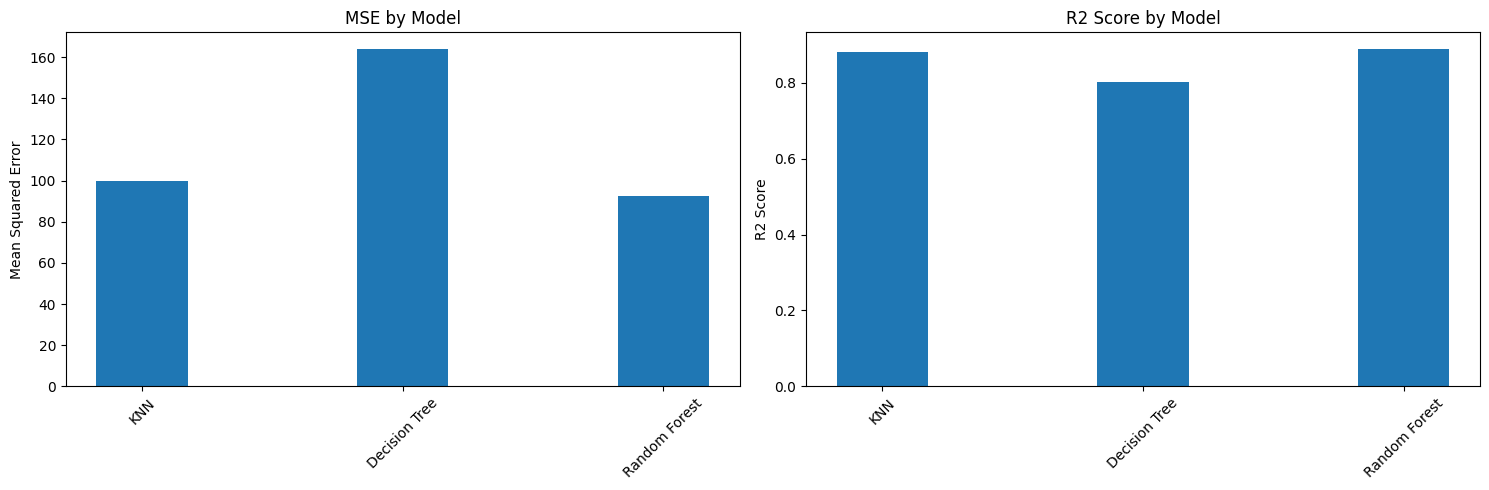

In [91]:
# Visualize model performance comparison
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Extract metrics
mse_scores = [metrics['MSE'] for metrics in results.values()]
r2_scores = [metrics['R2 Score'] for metrics in results.values()]
model_names = list(results.keys())

# Create bar plots
x = np.arange(len(model_names))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

ax1.bar(x, mse_scores, width, label='MSE')
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('MSE by Model')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45)

ax2.bar(x, r2_scores, width, label='R2')
ax2.set_ylabel('R2 Score') 
ax2.set_title('R2 Score by Model')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=45)

plt.tight_layout()
plt.show()


In [92]:
   import joblib
   joblib.dump(model, 'model.joblib')
   print('Model saved successfully!')

Model saved successfully!
